In [18]:
import numpy as np
from sklearn.datasets import make_regression

In [19]:
X,y = make_regression(n_samples=4,n_features=1,n_targets=1,n_informative=1,noise=80,random_state=13)

In [20]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [21]:
X.shape

(4, 1)

In [22]:
y

array([  7.21786552,  16.04609925, -27.83756166, 144.36688189])

In [6]:
y.shape

(442,)

## Using Sklearn's Linear Regression

In [23]:
from sklearn.model_selection import train_test_split

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
reg = LinearRegression()

In [35]:
reg.fit(X,y)

LinearRegression()

In [36]:
y_pred = reg.predict(X)

In [37]:
from sklearn.metrics import r2_score

In [38]:
r2_score(y,y)

1.0

In [39]:
reg.coef_

array([78.35063668])

In [40]:
reg.intercept_

np.float64(26.15963284313262)

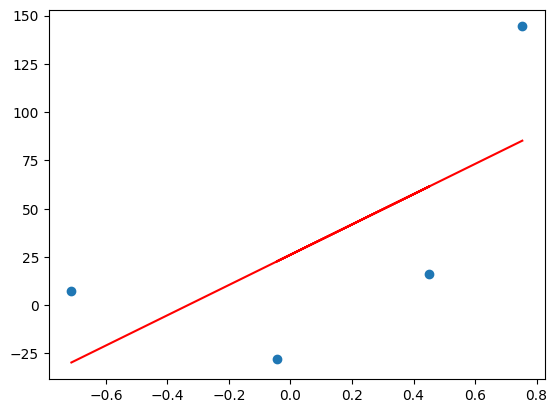

In [41]:
import matplotlib.pyplot as plt

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')
plt.show()

In [42]:
#Let's Apply Gradiet Descent assuming slope is constant 78.35
# lets assume b = 0 for starting

y_pred = ((78.35*X)+0).reshape(4)


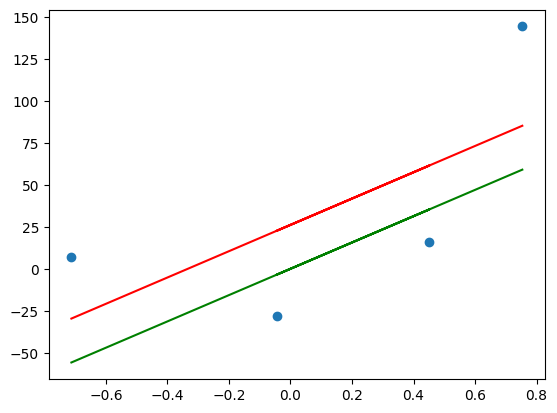

In [44]:
import matplotlib.pyplot as plt

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.show()

In [56]:
m = 78.35
b = 0

loss_slope = -2* np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [57]:
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [58]:
b = b - step_size
b

np.float64(20.927763408209216)

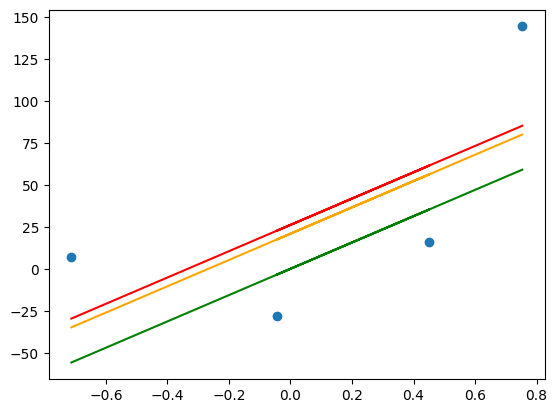

In [61]:
y_pred1 = ((78.35*X)+b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.plot(X,y_pred1,color='orange',label='b=20.92')
plt.show()


In [62]:
m = 78.35
b = 20.927763408209216

loss_slope = -2* np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [68]:
lr = 0.1
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [69]:
b = b - step_size
b

np.float64(25.11331608985106)

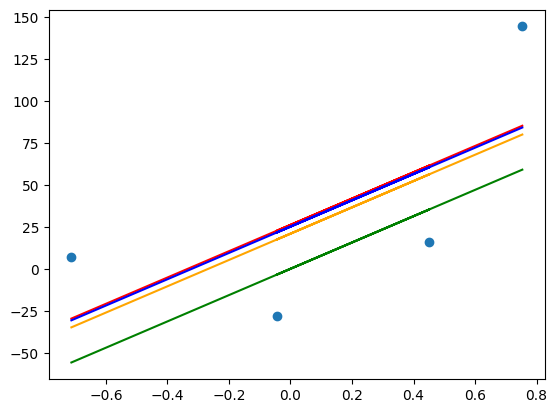

In [71]:
y_pred2 = ((78.35*X)+b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.plot(X,y_pred1,color='orange',label='b=20.92')
plt.plot(X,y_pred2,color='blue',label='b=25.11')
plt.show()


In [75]:
# iteration 3
m = 78.35
b = 25.11331608985106

loss_slope = -2* np.sum(y-m*X.ravel()-b)
loss_slope

lr = 0.1
step_size = loss_slope*lr
step_size

b = b - step_size
b

np.float64(25.95042662617943)

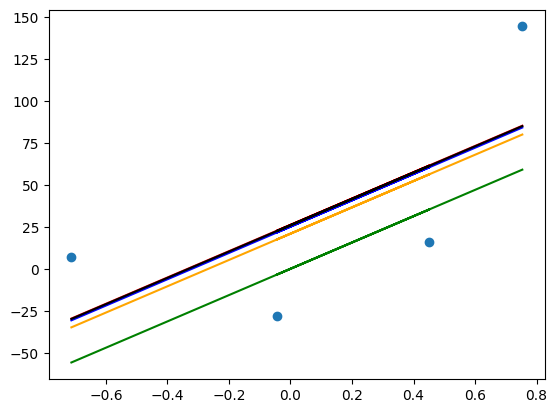

In [78]:
y_pred3 = ((78.35*X)+b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.plot(X,y_pred1,color='orange',label='b=20.92')
plt.plot(X,y_pred2,color='blue',label='b=25.11')
plt.plot(X,y_pred3,color='black',label='b=25.95')
plt.show()


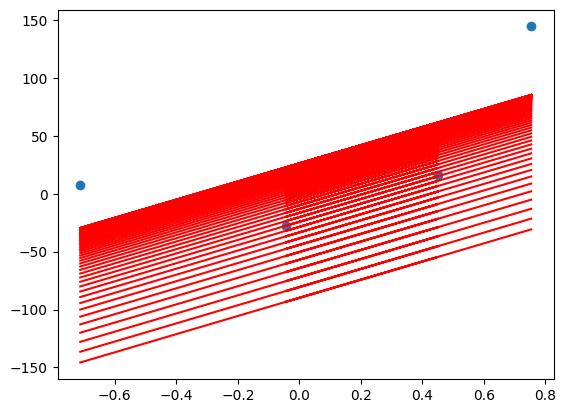

In [85]:
b = -100
m = 78.35

epochs = 100
lr = 0.01

for i in range(epochs):
  loss_slope = -2* np.sum(y-m*X.ravel()-b)
  step_size = loss_slope*lr
  b = b - step_size
  y_pred = m*X + b



  plt.plot(X,y_pred,color='red')

plt.scatter(X,y)



In [86]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [94]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

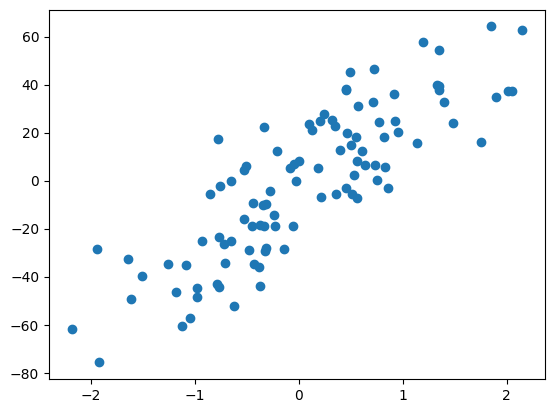

In [95]:
plt.scatter(X,y)

In [127]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [131]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score # Re-import r2_score function in case it was overwritten

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
r2_score_value=r2_score(y_test,y_pred) # Changed variable name to avoid conflict

print(lr.coef_)
print(lr.intercept_)
print(r2_score_value)

[28.12597332]
-2.2710144261783825
0.6345158782661012


In [ ]:
m =27.82809103

In [137]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            print(self.m,self.b,loss_slope_m,loss_slope_b)


        print(self.m,self.b)

    def predict(self,X):
        return self.m * X + self.b





In [138]:
gd = GDRegressor(0.001,100)
gd.fit(X,y)

88.7901778060777 -97.30202349511147 11209.822193922304 -22697.976504888527
79.26989400677363 -79.01269499728718 9520.283799304067 -18289.32849782429
71.19603915550572 -64.2700212110887 8073.854851267904 -14742.67378619848
64.357826042914 -52.381567622457695 6838.213112591715 -11888.453588631008
58.573134285938856 -42.79092431395032 5784.691756975142 -9590.643308507377
53.685100591058074 -35.05083591632167 4888.033694880779 -7740.088397628653
49.55898969983806 -28.80166573902754 4126.110891220014 -6249.170177294125
46.07935938462746 -23.754130522644466 3479.630315210599 -5047.535216383076
43.14751810732243 -19.6754551237646 2931.841277305026 -4078.675398879868
40.679264258689464 -16.378266564607884 2468.2538486329686 -3297.1885591567166
38.602889878179504 -13.711682863685132 2076.3743805099593 -2666.583700922752
36.85742837440565 -11.55416078082497 1745.4615037738538 -2157.5220828601614
35.391124246007365 -9.807753543980294 1466.3041283982818 -1746.4072368446764
34.160102562818395 -8.39

In [139]:
y_pred = gd.predict(X)

In [140]:
from sklearn.metrics import r2_score
r2_score(y,y_pred)

0.7035182396294904